# LOAN DEFAULT DATASET CLEANING
## THIS NOTE BOOK IS FOR EXPLORATORY ANALYSIS OF THE LOAN DATASET

The original csv file contains 215257 records and 102 fields.
Many of the fields were irrelevant to my cause, as I want to build a model that takes basic demographic and financial data and predict whether or not a loan applicant will default on his or her loan or not.

## CHOSEN COLUMNS
    'DAYS_AGE',
    'NAME_INCOME_TYPE',
    'DAYS_EMPLOYMENT',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'AMT_INCOME_TOTAL',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_HOUSING_TYPE',
    'AMT_CREDIT',
    'TARGET'

***The target column has only two kinds of response 0(For an applicant that didn't default) and 1 (For an applicant that default.***


## Missing Values
Only a few records had missing values in some columns, *i.e after picking my preferred columns*, so I decided to drop them as they were not many.

## FINAL DATA SHAPE
215255 records X 15 columns (including ID and Target)
**17448 were loan defaulters**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


In [28]:
df = pd.read_csv("data/train.csv")

In [29]:
df

,ID,NAME_CONTRACT_TYPE,GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_4,TARGET
0,160132,Cash loans,F,N,Y,0,427500.0,1288350.0,37800.0,1125000.0,...,0,0,0.0,0.0,1.0,0.0,0.0,5.0,0.242982,0
1,233132,Cash loans,M,Y,Y,0,180000.0,848745.0,40963.5,675000.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.115508,0
2,307771,Cash loans,M,Y,Y,1,112500.0,385164.0,19795.5,292500.0,...,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.393106,0
3,376452,Cash loans,F,N,Y,0,540000.0,1433520.0,60867.0,1237500.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.455985,0
4,405403,Cash loans,M,Y,Y,0,76500.0,900000.0,26316.0,900000.0,...,0,0,0.0,0.0,0.0,3.0,0.0,2.0,0.141508,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,308750,Cash loans,M,Y,N,0,144000.0,701730.0,70956.0,675000.0,...,0,0,0.0,0.0,0.0,0.0,1.0,1.0,0.139248,0
215253,451252,Cash loans,M,N,N,1,148500.0,254700.0,14751.0,225000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.135489,0
215254,103357,Cash loans,F,Y,Y,0,270000.0,1030500.0,30258.0,1030500.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.131298,0
215255,244766,Cash loans,F,N,Y,0,225000.0,433057.5,19206.0,324000.0,...,0,0,0.0,0.0,0.0,1.0,0.0,5.0,0.128493,1


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215257 entries, 0 to 215256
Columns: 102 entries, ID to TARGET
dtypes: float64(48), int64(40), object(14)
memory usage: 167.5+ MB


In [31]:
df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_AGE,DAYS_EMPLOYMENT,DAYS_ID_PUBLISH,OWN_CAR_AGE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_4,TARGET
count,215257.000000,215257.000000,2.152570e+05,2.152570e+05,215249.000000,2.150540e+05,215257.000000,215257.000000,215257.000000,73305.000000,...,215257.000000,215257.000000,186162.000000,186162.000000,186162.000000,186162.000000,186162.000000,186162.00000,2.147930e+05,215257.000000
mean,277916.285552,0.416567,1.683448e+05,5.996394e+05,27128.366938,5.388528e+05,-16040.968814,64138.989292,-2995.073206,12.053175,...,0.000506,0.000330,0.006494,0.006935,0.034486,0.268175,0.265264,1.90107,2.571639e-01,0.081057
std,102805.880546,0.721898,1.023409e+05,4.030145e+05,14521.116795,3.699160e+05,4367.736464,141546.368713,1509.053098,11.920288,...,0.022497,0.018158,0.084051,0.108859,0.203859,0.922865,0.860637,1.86733,1.850209e-01,0.272923
min,100002.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,-25201.000000,-17912.000000,-6383.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2.436734e-08,0.000000
25%,188825.000000,0.000000,1.125000e+05,2.700000e+05,16551.000000,2.385000e+05,-19697.000000,-2758.000000,-4298.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,9.779965e-02,0.000000
50%,277695.000000,0.000000,1.462500e+05,5.155290e+05,24930.000000,4.500000e+05,-15756.000000,-1209.000000,-3257.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,2.257796e-01,0.000000
75%,366772.000000,1.000000,2.025000e+05,8.086500e+05,34605.000000,6.795000e+05,-12409.000000,-288.000000,-1722.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.00000,3.940680e-01,0.000000
max,456255.000000,19.000000,9.000000e+06,4.050000e+06,230161.500000,4.050000e+06,-7676.000000,365243.000000,0.000000,91.000000,...,1.000000,1.000000,3.000000,9.000000,8.000000,27.000000,261.000000,25.00000,8.059096e-01,1.000000


In [32]:
# 1. Define the exact list of columns you want to keep
columns_to_keep = [
    'DAYS_AGE',
    'NAME_INCOME_TYPE',
    'DAYS_EMPLOYMENT',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'AMT_INCOME_TOTAL',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_HOUSING_TYPE',
    'AMT_CREDIT',
    'TARGET'
]

# 2. Subset the dataframe to only include these columns
# We create a new variable 'df_final' so you don't overwrite df_cleaned by mistake
df_final = df[columns_to_keep]

# Verify your final, lean dataframe
print("Final DataFrame Shape:", df_final.shape)
print("\nFirst 3 rows:")
print(df_final.head(3))

Final DataFrame Shape: (215257, 13)

First 3 rows:
   DAYS_AGE      NAME_INCOME_TYPE  DAYS_EMPLOYMENT  \
0    -22008             Pensioner           365243   
1     -8506  Commercial associate             -313   
2    -11579               Working            -2651   

             NAME_EDUCATION_TYPE    NAME_FAMILY_STATUS  CNT_CHILDREN  \
0  Secondary / secondary special                 Widow             0   
1  Secondary / secondary special  Single / not married             0   
2  Secondary / secondary special               Married             1   

   CNT_FAM_MEMBERS  AMT_INCOME_TOTAL FLAG_OWN_CAR FLAG_OWN_REALTY  \
0              1.0          427500.0            N               Y   
1              1.0          180000.0            Y               Y   
2              3.0          112500.0            Y               Y   

   NAME_HOUSING_TYPE  AMT_CREDIT  TARGET  
0  House / apartment   1288350.0       0  
1  House / apartment    848745.0       0  
2   Rented apartment    385164.0     

In [33]:
missing_counts = df_final.isnull().sum()

# (Optional) Filter to only show columns that actually have missing values > 0
missing_counts = missing_counts[missing_counts > 0]
print("--- Missing Values in Remaining Columns ---")
print(missing_counts)
print("\n")


# 2. Split into Numerical and Categorical so you can plan your imputation
# Grab just the columns from df_cleaned that have missing values
cols_with_missing = missing_counts.index

# Separate them by data type
numerical_cols = df_final[cols_with_missing].select_dtypes(include=['number']).columns
categorical_cols = df_final[cols_with_missing].select_dtypes(exclude=['number']).columns

print("--- Numerical Columns to fill with Median ---")
print(df_final[numerical_cols].isnull().sum())

print("\n--- Categorical Columns to fill with Mode/Unknown ---")
print(df_final[categorical_cols].isnull().sum())

--- Missing Values in Remaining Columns ---
CNT_FAM_MEMBERS    2
dtype: int64


--- Numerical Columns to fill with Median ---
CNT_FAM_MEMBERS    2
dtype: int64

--- Categorical Columns to fill with Mode/Unknown ---
Series([], dtype: float64)


In [34]:
rows_to_check = ['CNT_FAM_MEMBERS']
df_final = df_final.dropna(subset=rows_to_check)

In [35]:
df_final.shape

(215255, 13)

In [36]:
df_final

,DAYS_AGE,NAME_INCOME_TYPE,DAYS_EMPLOYMENT,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,AMT_CREDIT,TARGET
0,-22008,Pensioner,365243,Secondary / secondary special,Widow,0,1.0,427500.0,N,Y,House / apartment,1288350.0,0
1,-8506,Commercial associate,-313,Secondary / secondary special,Single / not married,0,1.0,180000.0,Y,Y,House / apartment,848745.0,0
2,-11579,Working,-2651,Secondary / secondary special,Married,1,3.0,112500.0,Y,Y,Rented apartment,385164.0,0
3,-21179,Pensioner,365243,Secondary / secondary special,Married,0,2.0,540000.0,N,Y,House / apartment,1433520.0,0
4,-21210,Working,-13767,Secondary / secondary special,Married,0,2.0,76500.0,Y,Y,House / apartment,900000.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,-18441,Working,-1540,Secondary / secondary special,Married,0,2.0,144000.0,Y,N,House / apartment,701730.0,0
215253,-10592,Working,-2360,Secondary / secondary special,Married,1,3.0,148500.0,N,N,With parents,254700.0,0
215254,-15598,Commercial associate,-2105,Incomplete higher,Civil marriage,0,2.0,270000.0,Y,Y,House / apartment,1030500.0,0
215255,-19451,Working,-1650,Secondary / secondary special,Separated,0,1.0,225000.0,N,Y,House / apartment,433057.5,1


In [37]:
df_final['AGE_YEARS'] = abs(df_final['DAYS_AGE']) // 365
df_final['YEARS_EMPLOYED'] = abs(df_final['DAYS_EMPLOYMENT']) // 365

df_final = df_final.drop(columns=['DAYS_AGE', 'DAYS_EMPLOYMENT'])
df_final

,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,AMT_CREDIT,TARGET,AGE_YEARS,YEARS_EMPLOYED
0,Pensioner,Secondary / secondary special,Widow,0,1.0,427500.0,N,Y,House / apartment,1288350.0,0,60,1000
1,Commercial associate,Secondary / secondary special,Single / not married,0,1.0,180000.0,Y,Y,House / apartment,848745.0,0,23,0
2,Working,Secondary / secondary special,Married,1,3.0,112500.0,Y,Y,Rented apartment,385164.0,0,31,7
3,Pensioner,Secondary / secondary special,Married,0,2.0,540000.0,N,Y,House / apartment,1433520.0,0,58,1000
4,Working,Secondary / secondary special,Married,0,2.0,76500.0,Y,Y,House / apartment,900000.0,0,58,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,Working,Secondary / secondary special,Married,0,2.0,144000.0,Y,N,House / apartment,701730.0,0,50,4
215253,Working,Secondary / secondary special,Married,1,3.0,148500.0,N,N,With parents,254700.0,0,29,6
215254,Commercial associate,Incomplete higher,Civil marriage,0,2.0,270000.0,Y,Y,House / apartment,1030500.0,0,42,5
215255,Working,Secondary / secondary special,Separated,0,1.0,225000.0,N,Y,House / apartment,433057.5,1,53,4


# NOTE:
The cell below takes care of the abnormal 1000 years employment age. and adds a new column FLAG_EMP_ANOMALY to track for and differentiate the abnormal cells from the regular cells for those with just 0 years of experience

In [38]:
abnormal_age_count = (df_final['AGE_YEARS'] > 70).sum()
print(f"Number of people over 70 years old: {abnormal_age_count}")

# 2. Count unrealistic employment lengths (e.g., working > 50 years)
abnormal_emp_count = (df_final['YEARS_EMPLOYED'] > 50).sum()
print(f"Number of people working > 50 years: {abnormal_emp_count}")

anomaly_value = 1000
df_final['YEARS_EMPLOYED'] = df_final['YEARS_EMPLOYED'].replace(anomaly_value, np.nan)
df_final['FLAG_EMP_ANOMALY'] = df_final['YEARS_EMPLOYED'].isnull().astype(int)
df_final['YEARS_EMPLOYED'] = df_final['YEARS_EMPLOYED'].fillna(0)

df_final

Number of people over 70 years old: 0
Number of people working > 50 years: 38952


,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,AMT_CREDIT,TARGET,AGE_YEARS,YEARS_EMPLOYED,FLAG_EMP_ANOMALY
0,Pensioner,Secondary / secondary special,Widow,0,1.0,427500.0,N,Y,House / apartment,1288350.0,0,60,0.0,1
1,Commercial associate,Secondary / secondary special,Single / not married,0,1.0,180000.0,Y,Y,House / apartment,848745.0,0,23,0.0,0
2,Working,Secondary / secondary special,Married,1,3.0,112500.0,Y,Y,Rented apartment,385164.0,0,31,7.0,0
3,Pensioner,Secondary / secondary special,Married,0,2.0,540000.0,N,Y,House / apartment,1433520.0,0,58,0.0,1
4,Working,Secondary / secondary special,Married,0,2.0,76500.0,Y,Y,House / apartment,900000.0,0,58,37.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,Working,Secondary / secondary special,Married,0,2.0,144000.0,Y,N,House / apartment,701730.0,0,50,4.0,0
215253,Working,Secondary / secondary special,Married,1,3.0,148500.0,N,N,With parents,254700.0,0,29,6.0,0
215254,Commercial associate,Incomplete higher,Civil marriage,0,2.0,270000.0,Y,Y,House / apartment,1030500.0,0,42,5.0,0
215255,Working,Secondary / secondary special,Separated,0,1.0,225000.0,N,Y,House / apartment,433057.5,1,53,4.0,0


# NOTE

A new column 'CREDIT_TO_INCOME_RATIO' was build to reduce the different currency problem because ratios are currency-agnostic

In [39]:
df_final['CREDIT_INCOME_RATIO'] = df_final['AMT_CREDIT'] / df_final['AMT_INCOME_TOTAL']
df_final['ADULT_IN_HOUSE'] = df_final['CNT_FAM_MEMBERS'] - df_final['CNT_CHILDREN']
df_final

,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,AMT_CREDIT,TARGET,AGE_YEARS,YEARS_EMPLOYED,FLAG_EMP_ANOMALY,CREDIT_INCOME_RATIO,ADULT_IN_HOUSE
0,Pensioner,Secondary / secondary special,Widow,0,1.0,427500.0,N,Y,House / apartment,1288350.0,0,60,0.0,1,3.013684,1.0
1,Commercial associate,Secondary / secondary special,Single / not married,0,1.0,180000.0,Y,Y,House / apartment,848745.0,0,23,0.0,0,4.715250,1.0
2,Working,Secondary / secondary special,Married,1,3.0,112500.0,Y,Y,Rented apartment,385164.0,0,31,7.0,0,3.423680,2.0
3,Pensioner,Secondary / secondary special,Married,0,2.0,540000.0,N,Y,House / apartment,1433520.0,0,58,0.0,1,2.654667,2.0
4,Working,Secondary / secondary special,Married,0,2.0,76500.0,Y,Y,House / apartment,900000.0,0,58,37.0,0,11.764706,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,Working,Secondary / secondary special,Married,0,2.0,144000.0,Y,N,House / apartment,701730.0,0,50,4.0,0,4.873125,2.0
215253,Working,Secondary / secondary special,Married,1,3.0,148500.0,N,N,With parents,254700.0,0,29,6.0,0,1.715152,2.0
215254,Commercial associate,Incomplete higher,Civil marriage,0,2.0,270000.0,Y,Y,House / apartment,1030500.0,0,42,5.0,0,3.816667,2.0
215255,Working,Secondary / secondary special,Separated,0,1.0,225000.0,N,Y,House / apartment,433057.5,1,53,4.0,0,1.924700,1.0


In [40]:
df_final['TARGET'].sum()

np.int64(17448)

In [41]:
df_final.describe()

,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,AMT_CREDIT,TARGET,AGE_YEARS,YEARS_EMPLOYED,FLAG_EMP_ANOMALY,CREDIT_INCOME_RATIO,ADULT_IN_HOUSE
count,215255.000000,215255.000000,2.152550e+05,2.152550e+05,215255.000000,215255.000000,215255.000000,215255.000000,215255.000000,215255.000000
mean,0.416571,2.150882,1.683434e+05,5.996391e+05,0.081057,43.447335,4.948350,0.180957,3.962231,1.734310
std,0.721900,0.910791,1.023395e+05,4.030163e+05,0.272924,11.965317,6.259011,0.384984,2.694621,0.441701
min,0.000000,1.000000,2.565000e+04,4.500000e+04,0.000000,21.000000,0.000000,0.000000,0.076190,1.000000
25%,0.000000,2.000000,1.125000e+05,2.700000e+05,0.000000,33.000000,0.000000,0.000000,2.018667,1.000000
50%,0.000000,2.000000,1.462500e+05,5.155290e+05,0.000000,43.000000,3.000000,0.000000,3.266640,2.000000
75%,1.000000,3.000000,2.025000e+05,8.086500e+05,0.000000,53.000000,7.000000,0.000000,5.168514,2.000000
max,19.000000,20.000000,9.000000e+06,4.050000e+06,1.000000,69.000000,49.000000,1.000000,84.736842,2.000000


## EXPLORATORY DATA ANALYSIS

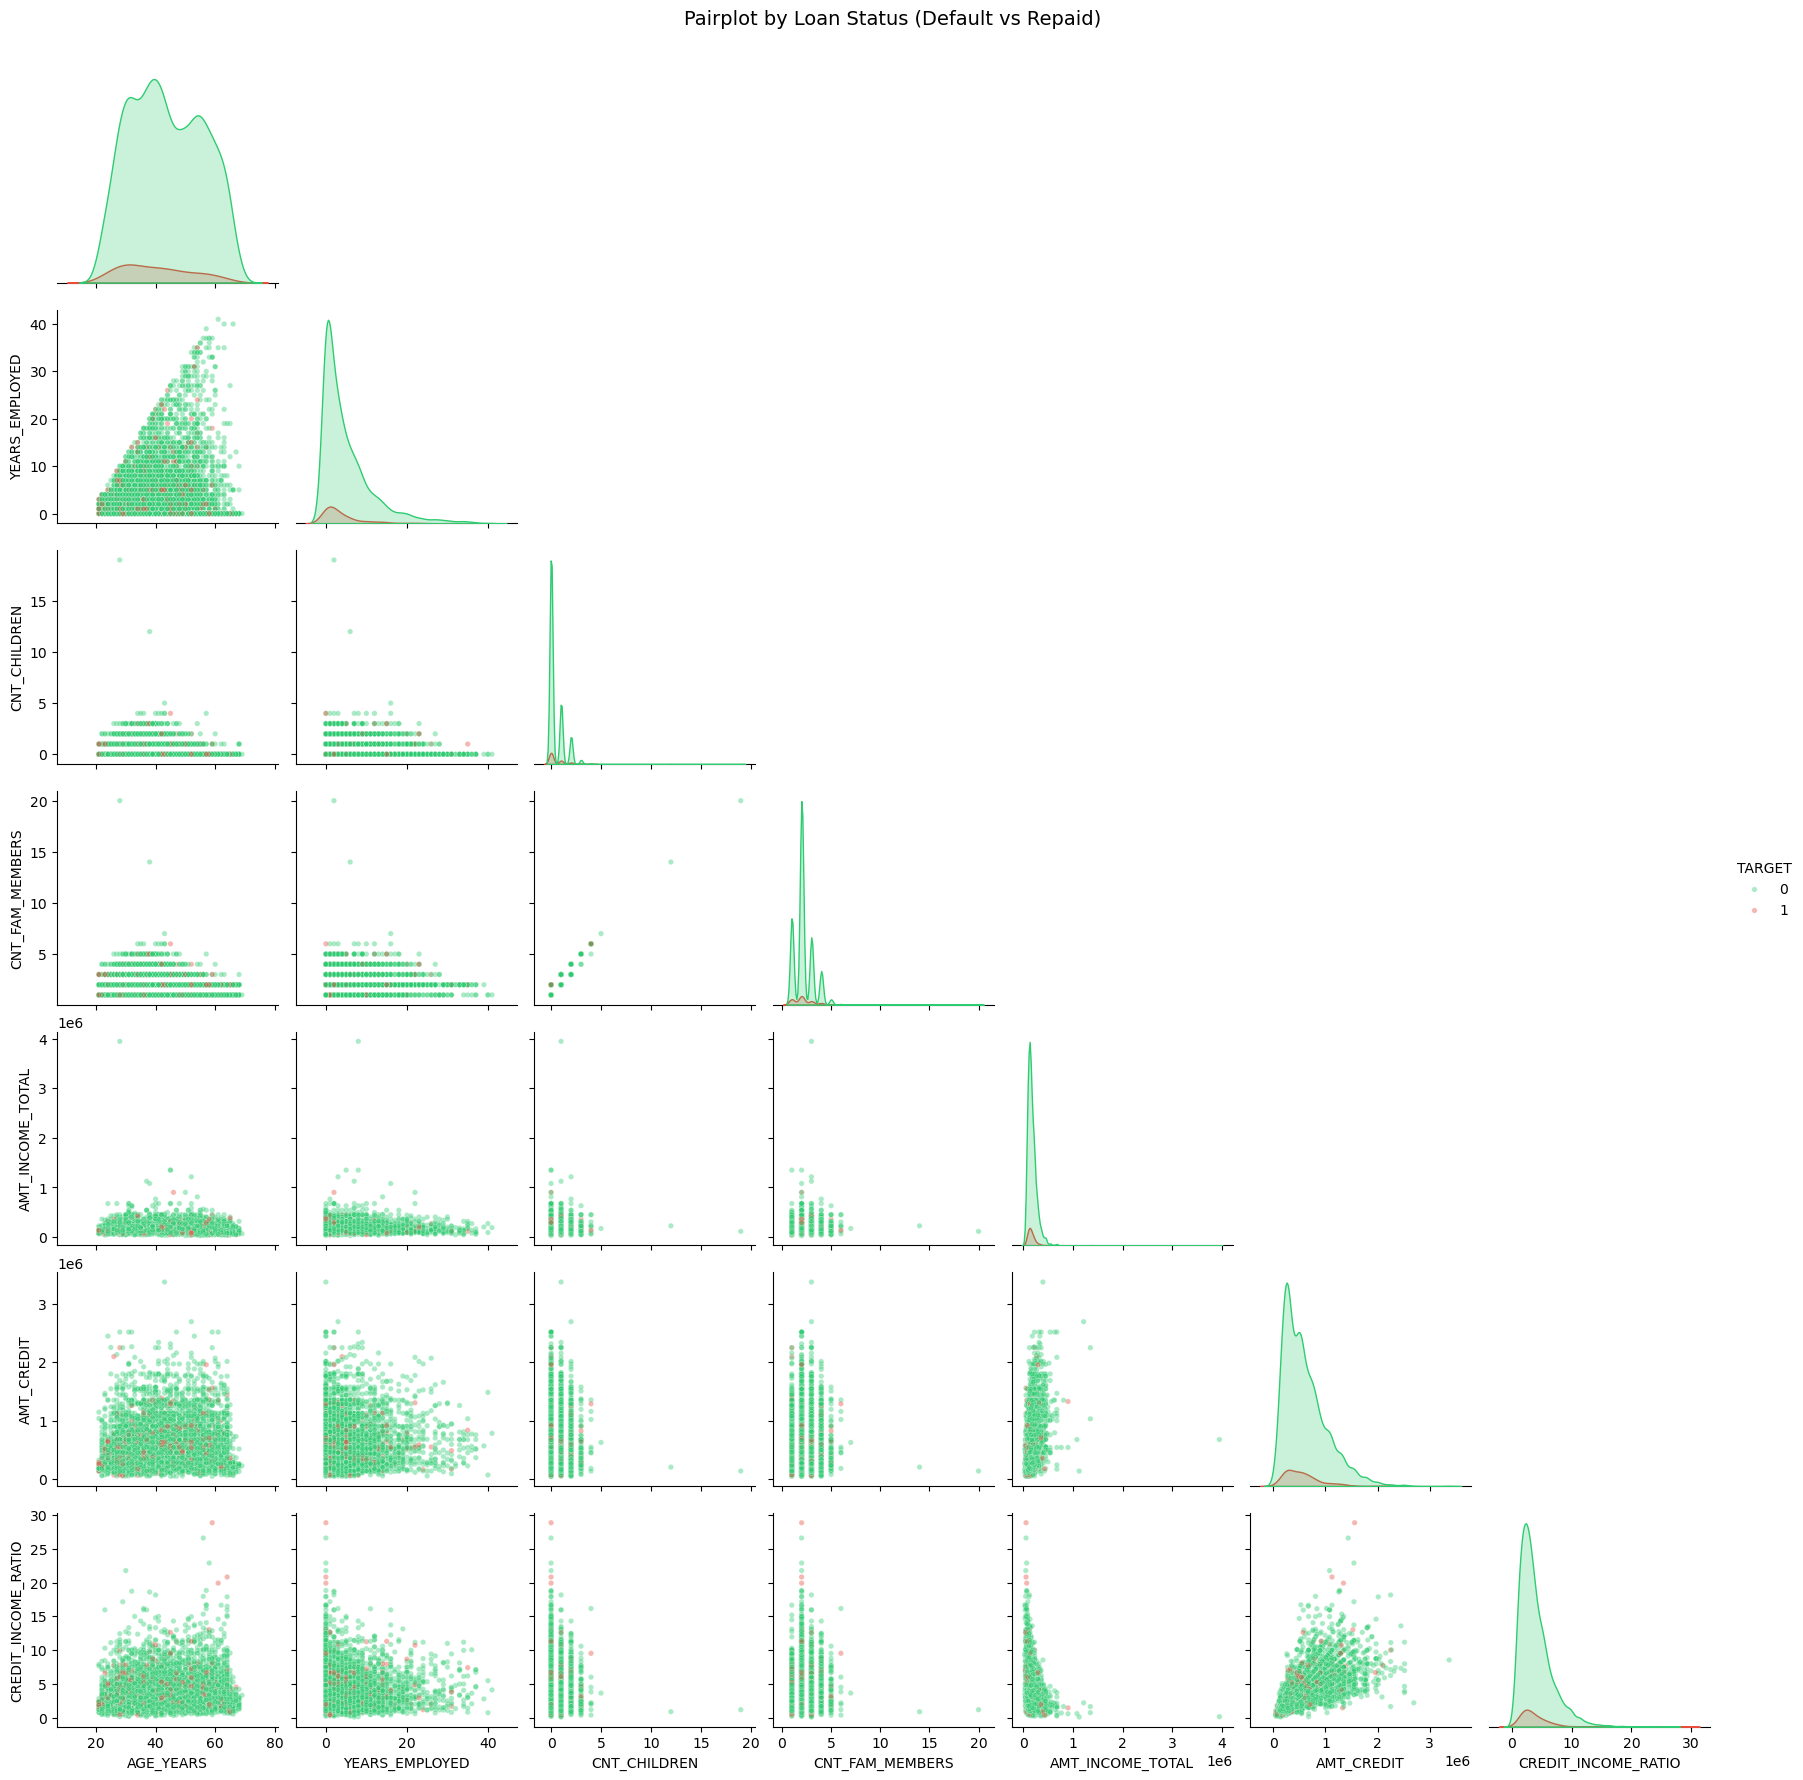

In [42]:
numerical_cols = [
    'AGE_YEARS', 'YEARS_EMPLOYED', 'CNT_CHILDREN', 
    'CNT_FAM_MEMBERS', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 
    'CREDIT_INCOME_RATIO'
]
# 1. Add your TARGET column to the list of numerical columns you want to plot
cols_for_pairplot = numerical_cols + ['TARGET']

# 2. Take your 5,000 row sample (CRITICAL: now including the TARGET column)
df_sample = df_final[cols_for_pairplot].sample(n=5000, random_state=42)

# 3. Draw the Pairplot with Color-Coding
sns.pairplot(
    df_sample, 
    hue='TARGET',                     # <--- THIS IS THE MAGIC PARAMETER
    diag_kind='kde', 
    corner=True, 
    palette={0: '#2ecc71', 1: '#e74c3c'},  # Green = Repaid (0), Red = Defaulted (1)
    plot_kws={'alpha': 0.4, 's': 15}       # alpha makes dots transparent, 's' makes them smaller
)

plt.suptitle("Pairplot by Loan Status (Default vs Repaid)", y=1.02, fontsize=14)
plt.show()

# Remark
It seems that CNT_CHILDREN AND CNT_FAM_MEMBERS are strongly correlated, however, I think it's is important we keep both, because a family of might have 2 adults (which could imply two potential breadwinning members) or just one adult (in this case one breadwinner). Ofcourse the relationship could be more complex, but it think this should suffice).

In [ ]:
# 1. Define the numerical features you want to test
features_for_tsne = [
    'AGE_YEARS', 'YEARS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'CREDIT_INCOME_RATIO'
]

# Ensure TARGET is included for color-coding
cols_to_keep = features_for_tsne + ['TARGET']

# 2. Sample the data to prevent memory crashes
# (We drop any lingering NaNs just in the sample so t-SNE doesn't throw an error)
df_tsne = df_final[cols_to_keep].dropna().sample(n=5000, random_state=42)

# Separate features (X) and target (y)
X_tsne = df_tsne[features_for_tsne]
y_tsne = df_tsne['TARGET']

# 3. Scale the features (CRITICAL step for t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tsne)

# 4. Initialize and run t-SNE
print("Running t-SNE... (this usually takes 30 to 60 seconds)")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
tsne_results = tsne.fit_transform(X_scaled)

# Add the resulting 2D coordinates back into our sample dataframe
df_tsne['tsne_1'] = tsne_results[:, 0]
df_tsne['tsne_2'] = tsne_results[:, 1]

# 5. Plot the Results
plt.figure(figsize=(12, 8))

# Draw the scatterplot
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='TARGET',
    # Green for Repaid (0), Red for Defaulted (1)
    palette={0: '#2ecc71', 1: '#e74c3c'}, 
    data=df_tsne,
    alpha=0.6,   # Slight transparency to see overlapping points
    s=40         # Size of the dots
)

plt.title("t-SNE Cluster Analysis: Default vs Repayment", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

# Clean up the legend
plt.legend(title='Loan Status', labels=['Repaid (0)', 'Defaulted (1)'])
plt.show()

Running t-SNE... (this usually takes 30 to 60 seconds)


In [ ]:
# The three categorical columns we want to explore
categorical_cols = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE']

print("--- Unique Categories and Frequencies ---")
for col in categorical_cols:
    print(f"\nFeature: {col}")
    # value_counts() gets the unique values AND sorts them by frequency
    print(df_final[col].value_counts())
    print("-" * 30)

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.tight_layout(pad=6.0)

for i, col in enumerate(categorical_cols):
    # Calculate the percentage of defaulters (TARGET mean) for each category
    # We multiply by 100 to make it a readable percentage (e.g., 8.5%)
    default_rates = df_final.groupby(col)['TARGET'].mean() * 100
    
    # Sort them so the highest risk categories are at the top
    default_rates = default_rates.sort_values(ascending=False).reset_index()

    # Draw the bar chart
    sns.barplot(
        x='TARGET', 
        y=col, 
        data=default_rates, 
        ax=axes[i],
        palette='Reds_r' # Red color scale for risk
    )
    
    axes[i].set_title(f"Default Risk by {col}")
    axes[i].set_xlabel("Percentage (%) Defaulted")
    axes[i].set_ylabel("")

plt.show()

In [ ]:
# 1. Clean Income Type
income_to_replace = ['Unemployed', 'Student', 'Businessman', 'Maternity leave']
df_final['NAME_INCOME_TYPE'] = df_final['NAME_INCOME_TYPE'].replace(income_to_replace, 'Other')

# 2. Clean Education Type
df_final['NAME_EDUCATION_TYPE'] = df_final['NAME_EDUCATION_TYPE'].replace(['Academic degree'], 'Higher education')

# 3. Clean Housing Type
housing_to_replace = ['Office apartment', 'Co-op apartment']
df_final['NAME_HOUSING_TYPE'] = df_final['NAME_HOUSING_TYPE'].replace(housing_to_replace, 'Other_Rented')
df_final['NAME_EDUCATION_TYPE'] = df_final['NAME_EDUCATION_TYPE'].replace('Secondary / secondary special', 'Secondary Education') 

# Verify the new, cleaner distributions
print(df_final['NAME_INCOME_TYPE'].value_counts())
print(df_final['NAME_HOUSING_TYPE'].value_counts())
print(df_final['NAME_EDUCATION_TYPE'].value_counts())

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.tight_layout(pad=6.0)

for i, col in enumerate(categorical_cols):
    # Calculate the percentage of defaulters (TARGET mean) for each category
    # We multiply by 100 to make it a readable percentage (e.g., 8.5%)
    default_rates = df_final.groupby(col)['TARGET'].mean() * 100
    
    # Sort them so the highest risk categories are at the top
    default_rates = default_rates.sort_values(ascending=False).reset_index()

    # Draw the bar chart
    sns.barplot(
        x='TARGET', 
        y=col, 
        data=default_rates, 
        ax=axes[i],
        palette='Reds_r' # Red color scale for risk
    )
    
    axes[i].set_title(f"Default Risk by {col}")
    axes[i].set_xlabel("Percentage (%) Defaulted")
    axes[i].set_ylabel("")

plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. The numerical columns you want to check
num_cols_to_check = [
    'AGE_YEARS', 'YEARS_EMPLOYED', 'CNT_CHILDREN', 
    'CNT_FAM_MEMBERS', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 
    'CREDIT_INCOME_RATIO'
]

# Set up a tall grid for our plots
fig, axes = plt.subplots(len(num_cols_to_check), 1, figsize=(10, 6 * len(num_cols_to_check)))
fig.tight_layout(pad=8.0)

for i, col in enumerate(num_cols_to_check):
    
    # 2. Chop the data into 5 equal-sized buckets (Quantiles)
    # duplicates='drop' handles columns like CNT_CHILDREN where many people have exactly 0
    df_final['TEMP_BIN'] = pd.qcut(df_final[col], q=5, duplicates='drop')
    
    # 3. Calculate the percentage of defaulters in each bucket
    risk_data = df_final.groupby('TEMP_BIN', observed=False)['TARGET'].mean() * 100
    risk_data = risk_data.reset_index()
    
    # Convert the intervals to strings so Seaborn plots them nicely on the X-axis
    risk_data['TEMP_BIN'] = risk_data['TEMP_BIN'].astype(str)
    
    # 4. Draw the Bar Chart
    sns.barplot(
        x='TEMP_BIN', 
        y='TARGET', 
        data=risk_data, 
        ax=axes[i], 
        palette='magma'
    )
    
    axes[i].set_title(f"Default Risk Trend: {col}", fontsize=14)
    axes[i].set_xlabel(f"{col} (Divided into 5 groups from Lowest to Highest)")
    axes[i].set_ylabel("Default Rate (%)")
    
    # Rotate the x-axis labels so the bin ranges are easy to read
    axes[i].tick_params(axis='x', rotation=45)

# Clean up by dropping the temporary bin column so it doesn't clutter your dataset
df_final = df_final.drop(columns=['TEMP_BIN'])

plt.show()

In [ ]:
# Save the cleaned dataframe to a new CSV file
df_final.to_csv('data/cleaned_loan_data.csv', index=False)

print("Success! The cleaned data has been saved as 'cleaned_loan_data.csv'")